In [1]:
import pandas as pd
from warnings import filterwarnings
import random

import torch.cuda as cuda
from scipy.sparse import csr_matrix
from scipy.io import mmread

from scformer.model import *
from scformer.utils import *

filterwarnings("ignore")
seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
os.environ["PYTHONHASHSEED"] = str(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [3]:
adata = sc.read_h5ad('../data/pbmc_benchmark_data/pbmc.h5ad')
mapping_dict = {
    'Naive CD20+ B IGKC+': 'Naïve CD20+ B',
    'Naive CD20+ B IGKC-': 'Naïve CD20+ B',
    'CD14+ Mono': 'CD14+ Mono',
    'HSC': 'HSC',
    'Reticulocyte': 'Erythroblast',
    'Normoblast': 'Normoblast',
    'NK CD158e1+': 'NK',
    'CD4+ T naive': 'CD4+ T naïve',
    'Erythroblast': 'Erythroblast',
    'NK': 'NK',
    'B1 B IGKC+': 'B1 B',
    'B1 B IGKC-': 'B1 B',
    'CD4+ T activated': 'CD4+ T activated',
    'CD4+ T activated integrinB7+': 'CD4+ T activated',
    'pDC': 'pDC',
    'Proerythroblast': 'Proerythroblast',
    'Transitional B': 'Transitional B',
    'MAIT': 'CD8+ T',
    'CD8+ T naive': 'CD8+ T naïve',
    'CD8+ T naive CD127+ CD26- CD101-': 'CD8+ T naïve',
    'T reg': 'CD4+ T activated',
    'CD8+ T CD49f+': 'CD8+ T',
    'CD8+ T TIGIT+ CD45RO+': 'CD8+ T',
    'gdT TCRVD2+': 'CD8+ T',  # gdT 类型被归入 CD8+ T
    'CD8+ T CD57+ CD45RA+': 'CD8+ T',
    'Lymph prog': 'Lymph prog',
    'Plasmablast IGKC+': 'Plasma cell',
    'Plasmablast IGKC-': 'Plasma cell',
    'CD8+ T CD69+ CD45RO+': 'CD8+ T',
    'CD8+ T TIGIT+ CD45RA+': 'CD8+ T',
    'CD8+ T CD69+ CD45RA+': 'CD8+ T',
    'ILC1': 'ILC',
    'cDC2': 'cDC2',
    'CD16+ Mono': 'CD16+ Mono',
    'G/M prog': 'G/Mprog',
    'MK/E prog': 'MK/E prog',
    'Plasma cell IGKC+': 'Plasma cell',
    'Plasma cell IGKC-': 'Plasma cell',
    'CD4+ T CD314+ CD45RA+': 'CD4+ T naïve',
    'ILC': 'ILC',
    'gdT CD158b+': 'CD8+ T',  # gdT 类型被归入 CD8+ T
    'CD8+ T CD57+ CD45RO+': 'CD8+ T',
    'dnT': None,  # 不需要的类型设为 None
    'cDC1': 'cDC2',  # 映射到 cDC2
    'T prog cycling': 'Lymph prog',  # 映射到 Lymph prog
}
adata.obs['Annotation'] = adata.obs['cell_type'].map(mapping_dict)
adata = adata[~adata.obs['Annotation'].isna()]

In [2]:
output_dir = '../output/pbmc_benchmark_data/'
os.makedirs(os.path.dirname(output_dir), exist_ok=True)

In [9]:
adata.write(output_dir + '/pbmc_benchmark.h5ad')

In [10]:
# adata = adata[adata.obs['batch'].isin(['s1d1', 's2d1', 's3d1', 's4d1'])]
adata_s1d1 = adata[adata.obs['batch'].isin(['s1d1'])]
adata_s1d1.write(output_dir + '/pbmc_benchmark_s1d1.h5ad')

In [3]:
adata_subset = sc.read_h5ad(output_dir + 'pbmc_benchmark_s1d1.h5ad')
batch_labels_list = None
enable_batch_correction = False

In [4]:
RNA_matrix = adata_subset.X.transpose()

cell_num = RNA_matrix.shape[1]
gene_num = RNA_matrix.shape[0]

cell_size = 30

initial_pre = initial_clustering(RNA_matrix)
cluster_ini_num = len(set(initial_pre))
ini_p1 = [int(i) for i in initial_pre]

indices, Node_Ids, dic = batch_select_whole(RNA_matrix, cell_size=cell_size, save_path=output_dir + 'graph_preprocess')
n_batch = len(indices)
device = torch.device("cuda" if cuda.is_available() else "cpu")

node_model = NDR_2(RNA_matrix, indices, ini_p1, n_hid=104, n_heads=8,
                   enable_batch_correction=enable_batch_correction,
                   batch_source=batch_labels_list,
                   n_layers=3, labsm=0.1, lr=0.0005, wd=0.1, device=device, num_types=2,
                   num_relations=2, epochs=100)
gnn, cell_emb, gene_emb, h = node_model.train_model(n_batch=n_batch)

	When the number of cells is less than or equal to 500, it is recommended to set the resolution value to 0.2.
	When the number of cells is within the range of 500 to 5000, the resolution value should be set to 0.5.
	When the number of cells is greater than 5000, the resolution value should be set to 0.8.
         Falling back to preprocessing with `sc.pp.pca` and default params.
正在将数据划分为批次并进行并行处理。请稍候...


处理批次: 100%|██████████| 175/175 [00:49<00:00,  3.57it/s]


The training process for the NodeDimensionReduction model has started. Please wait.


Epochs: 100%|██████████| 100/100 [49:32<00:00, 29.73s/it]

The training for the NodeDimensionReduction model has been completed.


In [5]:
ScFormer_result = pred(
    RNA_matrix, gnn=gnn, indices=indices, device=device
)
# Save numpy arrays to files
# output_file = "data/mouse_retina/output"
np.save(output_dir + "/Node_Ids.npy", Node_Ids)
np.save(output_dir + "/pred.npy", ScFormer_result["pred_label"])
np.save(output_dir + "/cell_embedding.npy", ScFormer_result["cell_embedding"])

Prediction Batches: 100%|██████████| 175/175 [00:24<00:00,  7.23it/s]


In [6]:
node_ids = np.load(output_dir + "/Node_Ids.npy")
cell_emb = np.load(output_dir + "/cell_embedding.npy")
cell_emb_ = pd.DataFrame(cell_emb, index=node_ids)
cell_emb_sorted = cell_emb_.sort_index()
adata_subset.obsm["cell_emb"] = cell_emb_sorted.values

In [7]:
pred = np.load(output_dir + '/pred.npy')
pred_ = pd.DataFrame(pred, index=Node_Ids)
pred_sorted = pred_.sort_index()
adata_subset.obs['pre'] = pred_sorted.values
adata_subset.obs['pre'] = adata_subset.obs['pre'].astype('category')

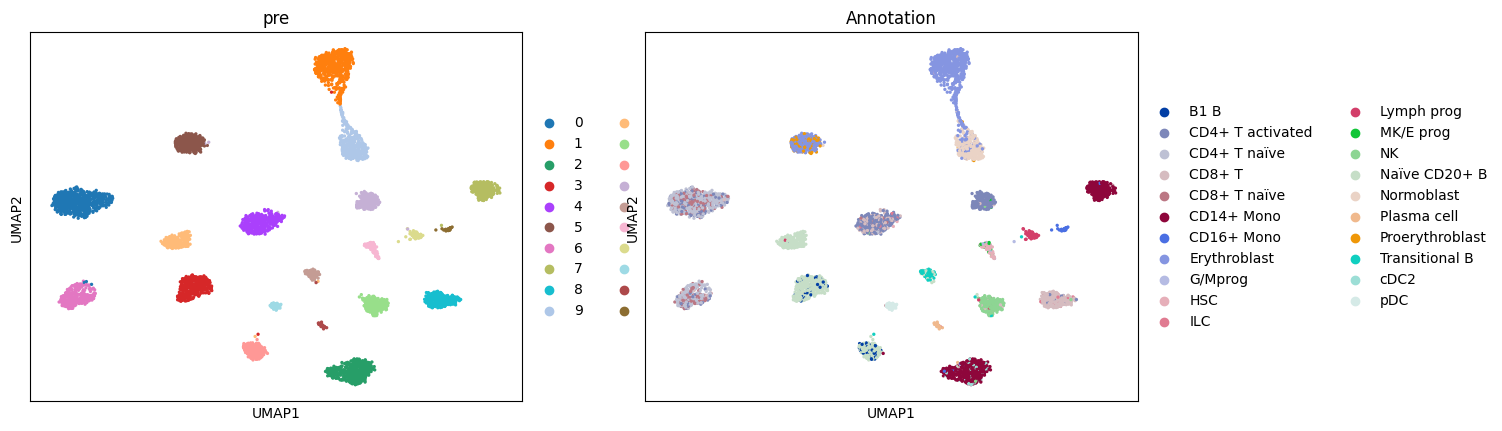

In [8]:
adata_subset.var_names_make_unique()
# sc.pp.log1p(adata_subset)
sc.pp.neighbors(adata_subset, use_rep="cell_emb")
sc.tl.umap(adata_subset)

sc.pl.umap(adata_subset, color=['pre', 'Annotation'], show=True)

In [9]:
from scformer.utils import (
    compute_ilisi,
    compute_ari,
    compute_nmi,
    compute_nn_entropy,
    compute_silhouette_score,
    compute_calinski_harabasz_score,
    compute_davies_bouldin_score,
)

# ilisi_score = compute_ilisi(corrected_data, labels)
nmi_score = compute_nmi(adata_subset.obs['Annotation'], adata_subset.obs['pre'])
ari_score = compute_ari(adata_subset.obs['Annotation'], adata_subset.obs['pre'])
# nn_entropy_scores = compute_nn_entropy(corrected_data, labels, k=30)
# print(ilisi_score, nmi_score, ari_score, nn_entropy_scores)
nmi_score, ari_score

(0.7514683864331618, 0.5294755098021019)

In [12]:
sc_score = compute_silhouette_score(adata_subset.obsm["cell_emb"], adata_subset.obs['pre'])
ch_score = compute_calinski_harabasz_score(adata_subset.obsm["cell_emb"], adata_subset.obs['pre'])
db_score = compute_davies_bouldin_score(adata_subset.obsm["cell_emb"], adata_subset.obs['pre'])
sc_score, ch_score, db_score

(0.7725976, 4264.981558367206, 0.5785643290831357)

In [4]:
sc.pp.filter_cells(adata, min_genes=200)  # 每个细胞至少表达200个基因
sc.pp.filter_genes(adata, min_cells=3)  # 每个基因至少在3个细胞中表达
adata.var['mt'] = adata.var_names.str.startswith('MT-')  # 假设线粒体基因以“MT-”开头
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]
sc.pp.normalize_total(adata, target_sum=1e4)  # 归一化到每个细胞的总表达量
sc.pp.log1p(adata)  # 对数变换
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
adata = adata[:, adata.var.highly_variable]
sc.pp.scale(adata, max_value=10)

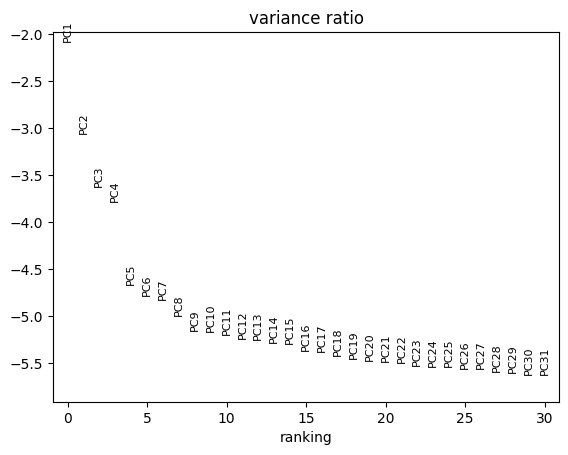

In [5]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True)

In [6]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)  # 设置近邻数和使用的主成分数量
sc.tl.leiden(adata, resolution=0.5)  # 使用 Leiden 聚类算法

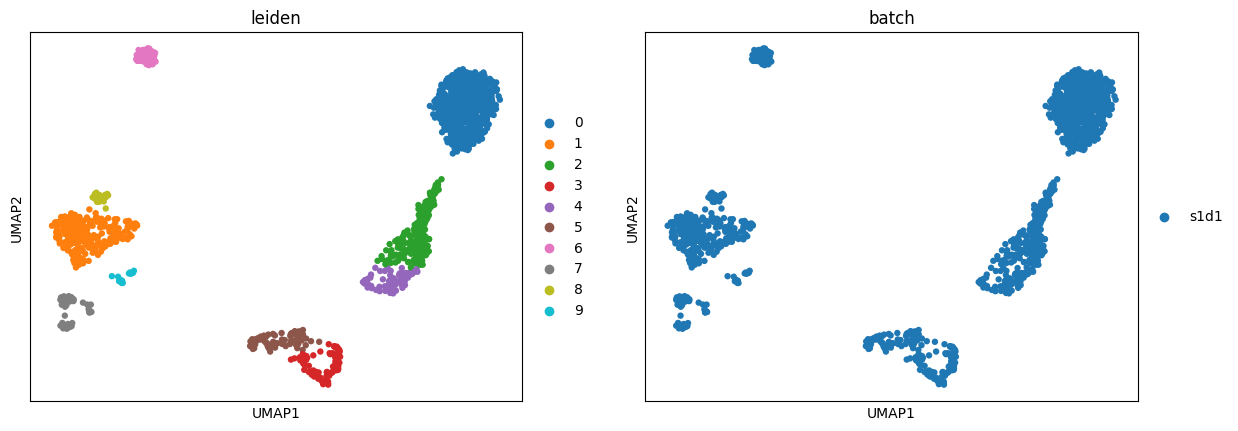

In [7]:
sc.tl.umap(adata)  # 计算UMAP
sc.pl.umap(adata, color=['leiden', 'batch'])  # 按聚类和基因表达可视化

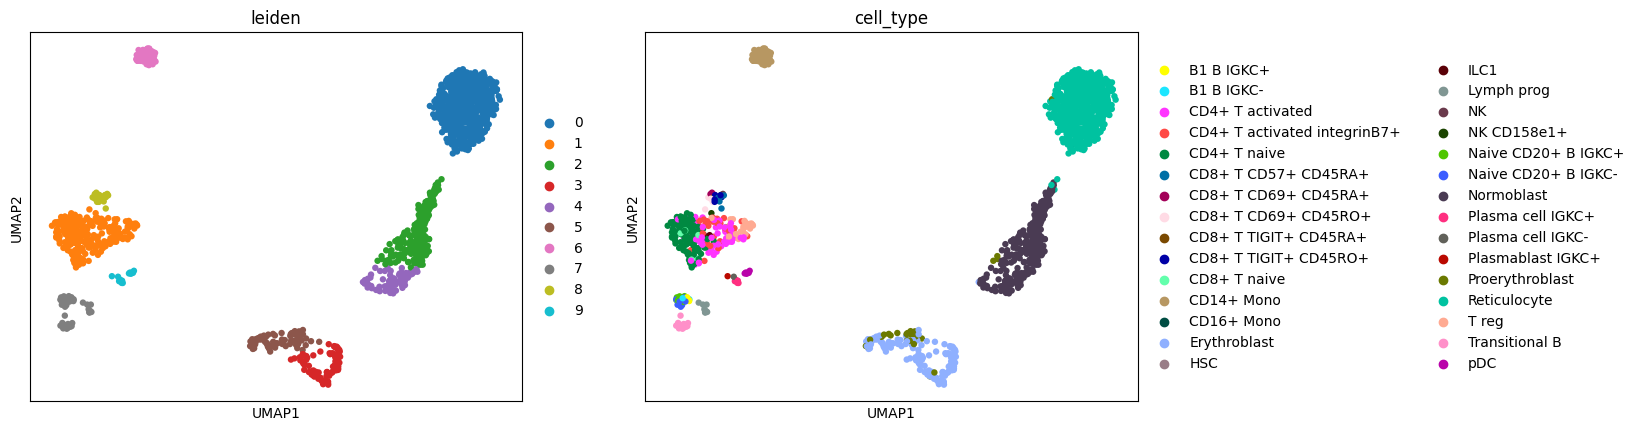

In [8]:
sc.pl.umap(adata, color=['leiden', 'cell_type'])

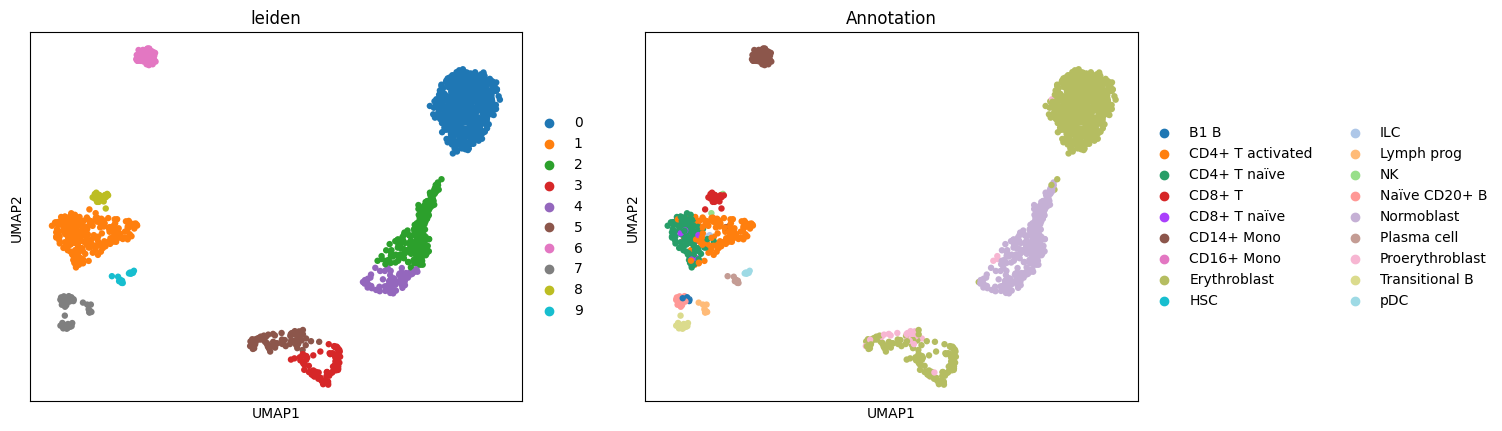

In [9]:
sc.pl.umap(adata, color=['leiden', 'Annotation'])

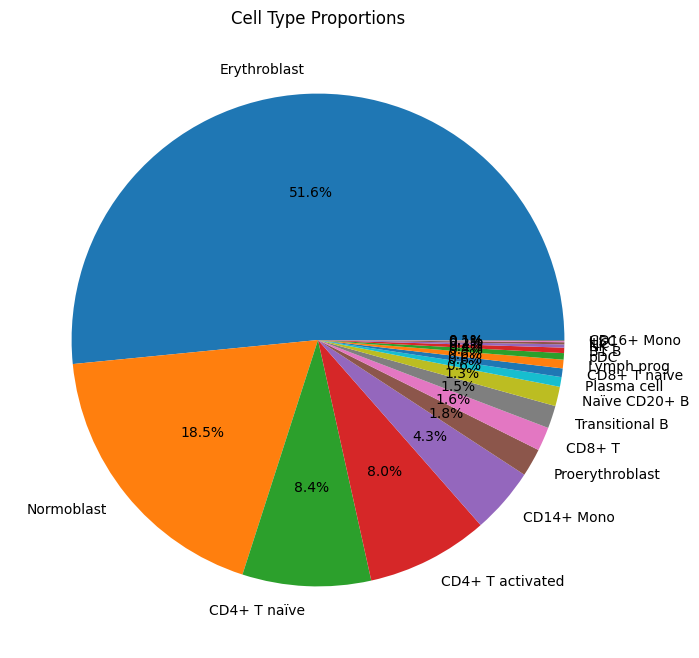

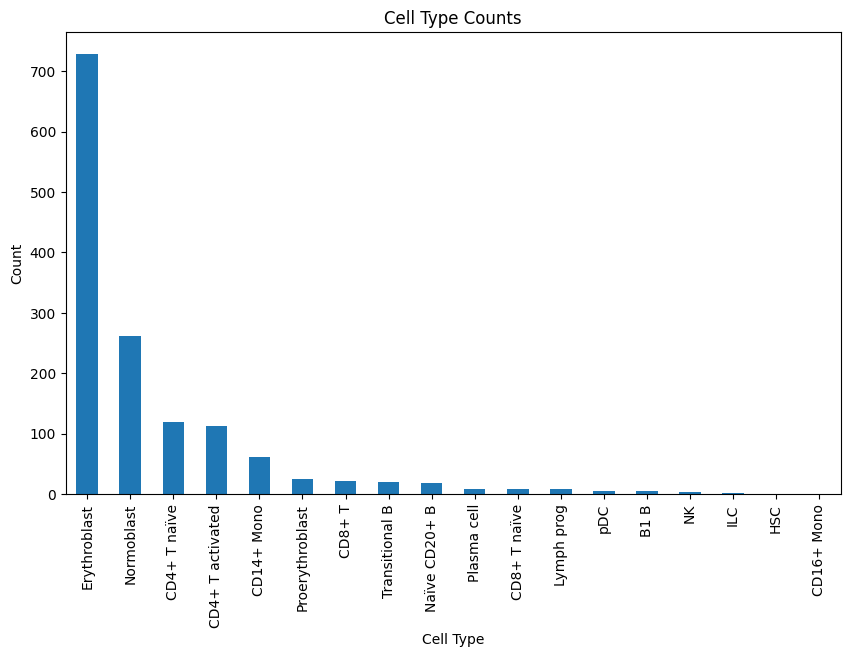

In [10]:
# 提取目标注释结果列
cell_types = adata.obs['Annotation']

# 统计每种类型细胞数量
cell_type_counts = cell_types.value_counts()

# 计算每种类型的细胞占比
cell_type_proportions = cell_type_counts / cell_type_counts.sum()

# 将结果合并为 DataFrame 以便查看
cell_type_summary = pd.DataFrame({
    'Cell Type': cell_type_counts.index,
    'Count': cell_type_counts.values,
    'Proportion': cell_type_proportions.values
})

# 显示结果
import matplotlib.pyplot as plt

# 饼图
cell_type_proportions.plot(kind='pie', autopct='%1.1f%%', figsize=(8, 8))
plt.title('Cell Type Proportions')
plt.ylabel('')
plt.show()

# 柱状图
cell_type_counts.plot(kind='bar', figsize=(10, 6))
plt.title('Cell Type Counts')
plt.xlabel('Cell Type')
plt.ylabel('Count')
plt.show()

In [11]:
# 计算每种类型的细胞数量和比例
cell_types = adata.obs['Annotation']
cell_type_counts = cell_types.value_counts()
cell_type_proportions = cell_type_counts / cell_type_counts.sum()

# 筛选比例在 1% 和 3% 之间的细胞类型
target_cell_types = cell_type_proportions[
    (cell_type_proportions > 0.01) & (cell_type_proportions < 0.03)
    ].index.tolist()

print("符合条件的细胞类型：", target_cell_types)


符合条件的细胞类型： ['Proerythroblast', 'CD8+ T', 'Transitional B', 'Naïve CD20+ B']


In [12]:
# 添加标记列，用于标记细胞是否属于目标范围
adata.obs['Target'] = adata.obs['Annotation'].isin(target_cell_types)


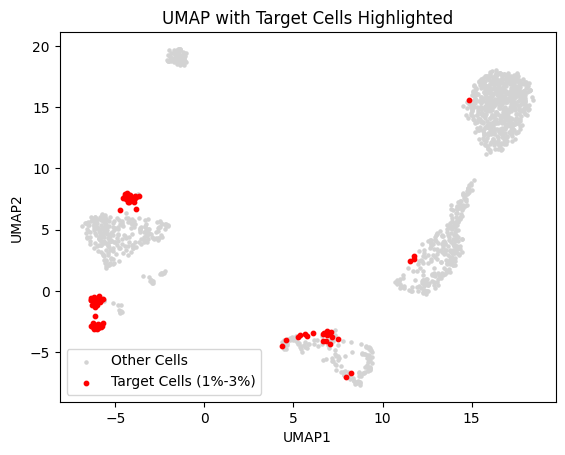

In [13]:
# 获取 UMAP 坐标
umap_data = adata.obsm['X_umap']

# 获取目标细胞的布尔值
target_mask = adata.obs['Target']

# 绘制非目标细胞
plt.scatter(
    umap_data[~target_mask, 0],
    umap_data[~target_mask, 1],
    c='lightgray', s=5, label='Other Cells'
)

# 绘制目标细胞
plt.scatter(
    umap_data[target_mask, 0],
    umap_data[target_mask, 1],
    c='red', s=10, label='Target Cells (1%-3%)'
)

plt.legend()
plt.title('UMAP with Target Cells Highlighted')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.show()
